In [ ]:
from google.colab import drive

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
import joblib
import string
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Load dataset
file_path = "/content/drive/MyDrive/Emotion_detection_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Emotion,Text,Clean_Text
0,0,neutral,Why ?,NaN
1,1,joy,Sage Act upgrade on my to do list for tommorow.,Sage Act upgrade list tommorow
2,2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...,WAY HOMEGIRL BABY FUNERAL MAN HATE FUNERALS SH...
3,3,joy,Such an eye ! The true hazel eye-and so brill...,eye true hazel eyeand brilliant Regular feat...
4,4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...,ugh babe hugggzzz u babe naamazed nga ako e...


In [ ]:
# Ensure correct column names
text_column = "Clean_Text"  # Adjusted to match dataset
label_column = "Emotion"

df = df[[text_column, label_column]].dropna()

In [ ]:
print(df.columns)


Index(['Clean_Text', 'Emotion'], dtype='object')


In [ ]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
nltk.download('all')


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
# Text Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return ' '.join(tokens)

df['processed'] = df[text_column].apply(preprocess_text)

In [ ]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_tfidf = tfidf.fit_transform(df['processed'])

In [ ]:
# Handle Class Imbalance
y = df[label_column]
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)

In [ ]:
# Train Model
model = LinearSVC(max_iter=10000)
model.fit(X_resampled, y_resampled)


LinearSVC(max_iter=10000)

In [ ]:
# Evaluate Model
y_pred = model.predict(X_resampled)
accuracy = accuracy_score(y_resampled, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.83


In [ ]:
# Classification Report and Confusion Matrix
print("\nClassification Report:")
print(classification_report(y_resampled, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_resampled, y_pred)
print(conf_matrix)


Classification Report:
              precision    recall  f1-score   support

       anger       0.82      0.76      0.79     11037
     disgust       0.88      0.94      0.91     11037
        fear       0.87      0.78      0.82     11037
         joy       0.77      0.73      0.75     11037
     neutral       0.71      0.94      0.81     11037
     sadness       0.79      0.65      0.71     11037
       shame       1.00      1.00      1.00     11037
    surprise       0.80      0.81      0.80     11037

    accuracy                           0.83     88296
   macro avg       0.83      0.83      0.82     88296
weighted avg       0.83      0.83      0.82     88296


Confusion Matrix:
[[ 8334   299   223   342  1109   463     4   263]
 [   79 10426    25    10   435    44     0    18]
 [  344   177  8627   375   856   334     0   324]
 [  385   291   388  8002   455   570     1   945]
 [  141    59    59    96 10426   176     0    80]
 [  605   376   431   814  1054  7149     3   605]


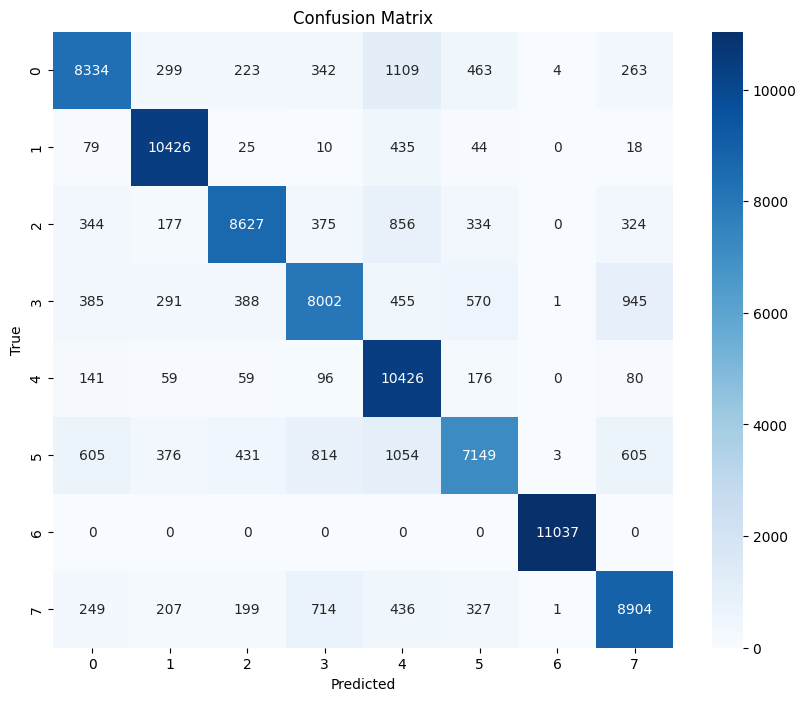

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
save_path = '/content/drive/MyDrive/1emotion_classifier.pkl'  # Change 'MyDrive' to your Drive folder if necessary
joblib.dump(model, save_path)
tfidf_save_path = '/content/drive/MyDrive/2tfidf_vectorizer.pkl'  # Change 'MyDrive' to your Drive folder if necessary
joblib.dump(tfidf, tfidf_save_path)


['/content/drive/MyDrive/2tfidf_vectorizer.pkl']

In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.8 MB/s eta 0:00:00


In [ ]:
import joblib
import string
import nltk
import ipywidgets as widgets
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download('punkt')
nltk.download('wordnet')

# Load the model and TF-IDF vectorizer
model_path = '/content/drive/MyDrive/1emotion_classifier.pkl'  # Update with your local model path in Colab
tfidf_path = '/content/drive/MyDrive/2tfidf_vectorizer.pkl'  # Update with your local tfidf path in Colab
model = joblib.load(model_path)
tfidf = joblib.load(tfidf_path)

# Text preprocessing function
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Create a text box and button for user input
text_area = widgets.Textarea(
    description='Enter Text:',
    placeholder='Type your text here...',
    layout=widgets.Layout(width='80%')
)

predict_button = widgets.Button(description="Predict Emotion", button_style='primary')

# Output area to display prediction
output = widgets.Output()

def on_button_click(b):
    with output:
        # Get the user input
        user_input = text_area.value

        # Check if input is provided
        if user_input.strip():
            processed_text = preprocess_text(user_input)
            text_vectorized = tfidf.transform([processed_text])
            prediction = model.predict(text_vectorized)[0]
            print(f"Predicted Emotion: {prediction}")
        else:
            print("Please enter some text to analyze.")

# Bind the button click to the function
predict_button.on_click(on_button_click)

# Display the widgets in the notebook
display(text_area, predict_button, output)


Textarea(value='', description='Enter Text:', layout=Layout(width='80%'), placeholder='Type your text here...'…

Button(button_style='primary', description='Predict Emotion', style=ButtonStyle())

Output()